# Cell 1 : FP Growth (tìm điều kiện năng suất cao)

Cần rời rạc hóa dữ liệu.


Discretize dữ liệu

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\crop_processed.csv"
)

In [4]:
df.head()

,Unnamed: 0,Area,Item,Year,yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,0,1,1990,36613,0.473294,-0.616366,-0.661069
1,1,0,3,1990,66667,0.473294,-0.616366,-0.661069
2,2,0,4,1990,23333,0.473294,-0.616366,-0.661069
3,3,0,5,1990,12500,0.473294,-0.616366,-0.661069
4,4,0,6,1990,7000,0.473294,-0.616366,-0.661069


In [5]:
df["temp_bin"] = pd.cut(
df["avg_temp"],
3,
labels=["low","medium","high"]
)

df["rain_bin"] = pd.cut(
df["average_rain_fall_mm_per_year"],
3,
labels=["low","medium","high"]
)

df["yield_bin"] = pd.cut(
df["yield"],
3,
labels=["low","medium","high"]
)

df.head()

,Unnamed: 0,Area,Item,Year,yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,temp_bin,rain_bin,yield_bin
0,0,0,1,1990,36613,0.473294,-0.616366,-0.661069,medium,medium,low
1,1,0,3,1990,66667,0.473294,-0.616366,-0.661069,medium,medium,low
2,2,0,4,1990,23333,0.473294,-0.616366,-0.661069,medium,medium,low
3,3,0,5,1990,12500,0.473294,-0.616366,-0.661069,medium,medium,low
4,4,0,6,1990,7000,0.473294,-0.616366,-0.661069,medium,medium,low


# Cell 2 : Rời rạc hóa dữ liệu (Discretization)

Association rule không dùng dữ liệu liên tục, nên cần chia thành Low / Medium / High.

### Rainfall

In [9]:
df["rainfall_level"] = pd.cut(
df["average_rain_fall_mm_per_year"],
bins=3,
labels=["Low","Medium","High"]
)

### Temperature

In [13]:
df["temp_level"] = pd.cut(
df["avg_temp"],
bins=3,
labels=["Low","Medium","High"]
)

### Yield


In [18]:
df["yield_level"] = pd.cut(
df["yield"],
bins=3,
labels=["Low","Medium","High"]
)

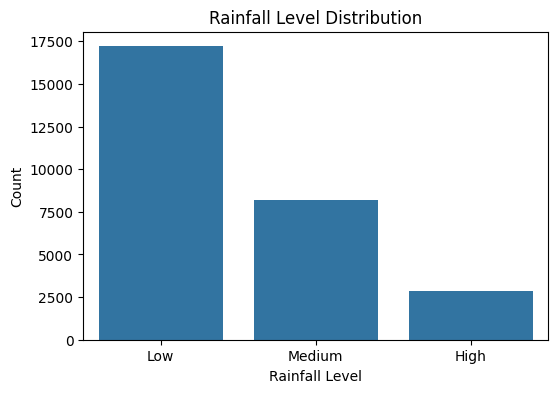

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(x="rainfall_level", data=df)

plt.title("Rainfall Level Distribution")

plt.xlabel("Rainfall Level")

plt.ylabel("Count")

plt.show()

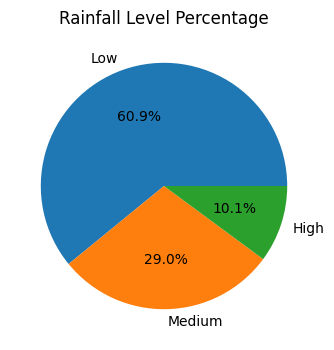

In [35]:
rain_counts = df["rainfall_level"].value_counts()

plt.figure(figsize=(6,4))

plt.pie(
rain_counts,
labels=rain_counts.index,
autopct="%1.1f%%"
)

plt.title("Rainfall Level Percentage")

plt.show()

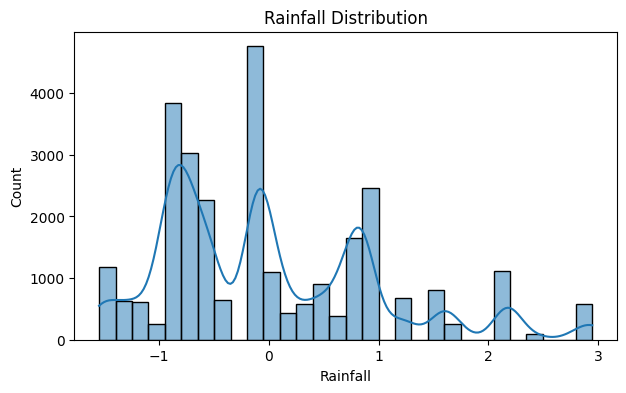

In [36]:
plt.figure(figsize=(7,4))

sns.histplot(
df["average_rain_fall_mm_per_year"],
bins=30,
kde=True
)

plt.title("Rainfall Distribution")

plt.xlabel("Rainfall")

plt.show()

In [38]:
df = df.rename(columns={"hg/ha_yield": "yield"})

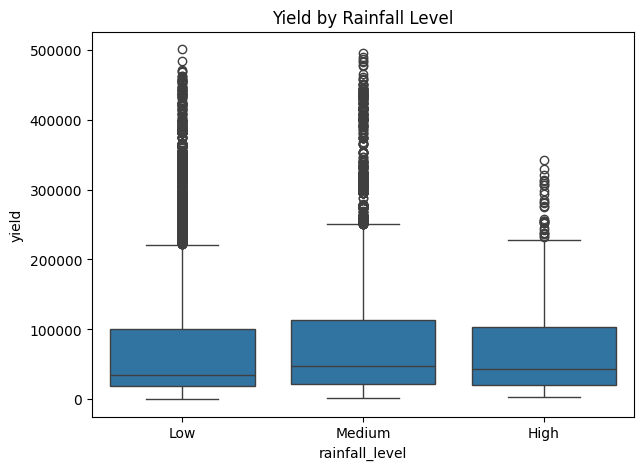

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(
x="rainfall_level",
y="yield",
data=df
)

plt.title("Yield by Rainfall Level")

plt.show()

# Cell 3 : Chuẩn bị dữ liệu cho Association Rules


In [19]:
basket = pd.get_dummies(
df[["rainfall_level","temp_level","yield_level"]]
)

basket.head()

,rainfall_level_Low,rainfall_level_Medium,rainfall_level_High,temp_level_Low,temp_level_Medium,temp_level_High,yield_level_Low,yield_level_Medium,yield_level_High
0,False,True,False,False,True,False,True,False,False
1,False,True,False,False,True,False,True,False,False
2,False,True,False,False,True,False,True,False,False
3,False,True,False,False,True,False,True,False,False
4,False,True,False,False,True,False,True,False,False


# Cell 4 : FP-Growth


In [20]:
frequent_itemsets = fpgrowth(
basket,
min_support=0.1,
use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.861695,frozenset({yield_level_Low})
1,0.353233,frozenset({temp_level_Medium})
2,0.289781,frozenset({rainfall_level_Medium})
3,0.117909,frozenset({yield_level_Medium})
4,0.609093,frozenset({rainfall_level_Low})


# Cell 5 : Association Rules


In [21]:
rules = association_rules(
frequent_itemsets,
metric="confidence",
min_threshold=0.6
)

rules.sort_values("lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,"frozenset({temp_level_High, rainfall_level_Med...",frozenset({yield_level_Low}),0.146059,0.861695,0.137172,0.939152,1.089888,1.0,0.011313,2.272935,0.096581,0.157563,0.560040,0.549170
1,frozenset({temp_level_Medium}),frozenset({rainfall_level_Low}),0.353233,0.609093,0.222753,0.630613,1.035332,1.0,0.007602,1.058260,0.052765,0.301192,0.055053,0.498163
3,"frozenset({yield_level_Low, temp_level_Medium})",frozenset({rainfall_level_Low}),0.294845,0.609093,0.185327,0.628558,1.031957,1.0,0.005739,1.052403,0.043916,0.257896,0.049794,0.466412
8,frozenset({temp_level_High}),frozenset({yield_level_Low}),0.534842,0.861695,0.473727,0.885733,1.027896,1.0,0.012856,1.210366,0.058343,0.513353,0.173804,0.717747
4,frozenset({rainfall_level_Medium}),frozenset({yield_level_Low}),0.289781,0.861695,0.252673,0.871945,1.011895,1.0,0.002970,1.080043,0.016552,0.281122,0.074111,0.582587
7,frozenset({rainfall_level_Low}),frozenset({yield_level_Low}),0.609093,0.861695,0.512889,0.842053,0.977205,1.0,-0.011964,0.875641,-0.056312,0.535430,-0.142021,0.718631
9,"frozenset({rainfall_level_Low, temp_level_High})",frozenset({yield_level_Low}),0.294986,0.861695,0.247752,0.839875,0.974678,1.0,-0.006437,0.863730,-0.035541,0.272575,-0.157769,0.563696
0,frozenset({temp_level_Medium}),frozenset({yield_level_Low}),0.353233,0.861695,0.294845,0.834703,0.968676,1.0,-0.009534,0.836705,-0.047618,0.320454,-0.195164,0.588436
2,"frozenset({rainfall_level_Low, temp_level_Medi...",frozenset({yield_level_Low}),0.222753,0.861695,0.185327,0.831982,0.965518,1.0,-0.006619,0.823155,-0.043930,0.206120,-0.214838,0.523527
5,"frozenset({temp_level_Medium, rainfall_level_M...",frozenset({yield_level_Low}),0.123150,0.861695,0.102188,0.829787,0.962971,1.0,-0.003929,0.812540,-0.042012,0.115773,-0.230709,0.474188


### Visualization luật


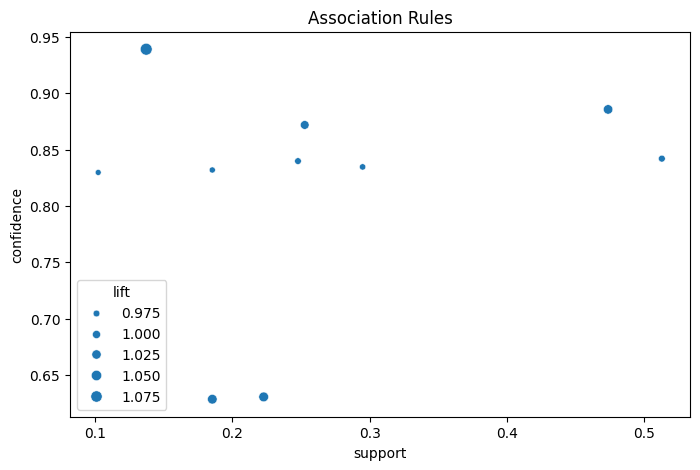

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
x="support",
y="confidence",
size="lift",
data=rules
)

plt.title("Association Rules")

plt.show()

### Insight

The association rules reveal environmental conditions that lead to higher crop yield.

For example:

- Medium rainfall and medium temperature tend to produce high yield.
- Extremely high or low rainfall conditions often lead to lower yield.

These rules can help farmers identify optimal growing conditions.

# Cell 6 : Clustering vùng trồng

Mục tiêu: phân cụm điều kiện môi trường

Feature dùng:

- rainfall

- temperature

- pesticides

Chọn feature :


In [23]:
X = df[
[
"average_rain_fall_mm_per_year",
"pesticides_tonnes",
"avg_temp"
]
]

# Cell 7 :Tìm số cluster tối ưu (Elbow)

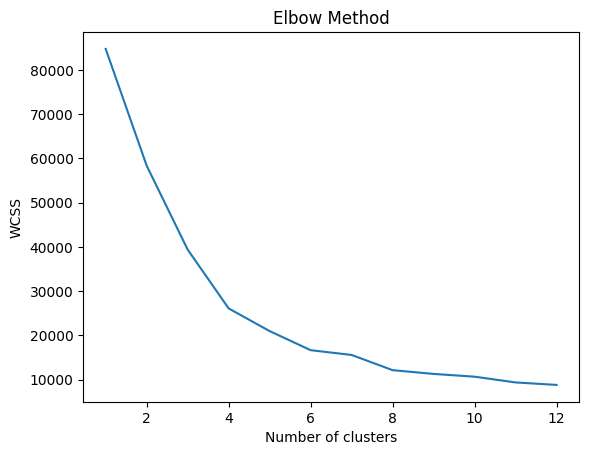

In [25]:
wcss = []

for i in range(1,13):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,13), wcss)

plt.xlabel("Number of clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Cell 10 :KMeans clustering

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X)

Visualization cluster

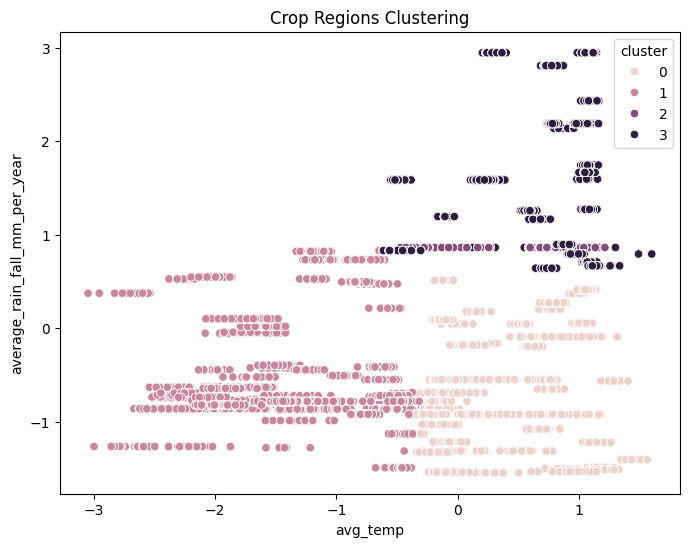

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x="avg_temp",
y="average_rain_fall_mm_per_year",
hue="cluster",
data=df
)

plt.title("Crop Regions Clustering")

plt.show()

### So sánh Yield giữa các cluster

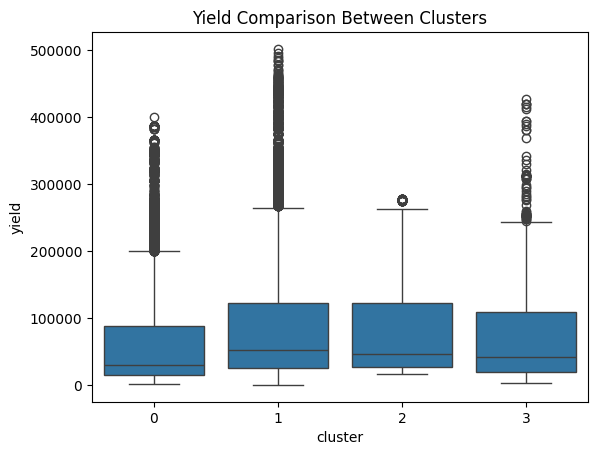

In [28]:
sns.boxplot(
x="cluster",
y="yield",
data=df
)

plt.title("Yield Comparison Between Clusters")

plt.show()

## Lưu dataset có cluster

In [29]:
df.to_csv(
r"D:\HocTap\DATA_MINING\DATA_MINING_PROJECT\data\processed\crop_clustered.csv",
index=False
)